In [2]:
import valenspy
import seaborn as sns
import xarray as xr
import matplotlib.pyplot as plt
from xclim.indicators.atmos import cooling_degree_days

variables = ["pr","tas", "tasmax", "tasmin"]
period=["1980","2014"]
frequency=["day","daily"]

time_decorder = xr.coders.CFDatetimeCoder() #Dealing with different calendars

xarray_open_kwargs = {
    "chunks": {"time": 1},
    "decode_times": time_decorder,
    "decode_coords": "all",
}

In [3]:
#Creating the input manager and adding our personal yml file to the catalog
m = valenspy.InputManager("bilan") #This takes very long for the all the CORDEX data...  

/mnt/netapp/home/kvandela/Projects/ValEnsPy/src/valenspy/input/esm_catalog_builder.py:111: UserWarning: Dataset CMIP6 is missing the required identifier 'version' in its pattern or metadata.
  warnings.warn(f"Dataset {dataset_name} is missing the required identifier '{identifier}' in its pattern or metadata.")


Processing dataset: CLIMATE_GRID
Processing dataset: CMIP5_CORDEX_BC_CLIMATE_GRID
Processing dataset: CMIP6
There are files that were skipped during the catalog creation. Please check the skipped_files property for a list of skipped files.


In [4]:
cat = m.search(
    source_type=["CMIP6"],
    experiment_id=["historical"],
    time_period=["2000","2001"]
)
cat.unique()

source_id              [ACCESS-ESM1-5, AWI-CM-1-1-MR, ACCESS-CM2, AWI...
source_type                                                      [CMIP6]
experiment_id                                               [historical]
version                                                               []
resolution                                                    [50-250km]
institution_id                                                 [default]
domain_id                                                       [global]
variable_id            [pr, sfcWind, tas, tasmax, tasmin, huss, uas, ...
frequency                                                          [day]
domain_id2                                                            []
path                   [/mnt/HDS_AFTER/AFTER/bertvs/CMIP6_raw_day/ACC...
time_period_start      [2000-01-01 00:00:00, 2001-01-01 00:00:00, 185...
time_period_end        [2014-12-31 23:59:59.999999999, 2000-12-31 23:...
driving_source_id                                  

In [5]:
# Set the scheduler to 'processes' for parallel processing.
import dask
dask.config.set(scheduler='processes')

import os
os.environ['OPENBLAS_NUM_THREADS'] = '1'

ids = m.unique()['source_id']
ids.remove("CESM2-WACCM-FV2") #Removed froom the list due to not having monotonic global attributes
ids.remove("ICON-ESM-LR") #Removed from the list due to the fact that it has latitude and longitude coordinates not lat and lon - this could easily be fixed in the future

dt = m.search(
    source_type=["CMIP6"],
    experiment_id=["historical"],
    source_id=ids,
    time_period=period,
    variable_id=["pr"],
).to_datatree(
    xarray_open_kwargs=xarray_open_kwargs,
    xarray_combine_by_coords_kwargs={
        "coords": "different",
    },
    levels=["source_id", "realization"]
)


--> The keys in the returned dictionary of datasets are constructed as follows:
	'source_id/realization'


/home/kvandela/fileserver/home/Projects/conda_envs/valenspy_dev/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'pr' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/kvandela/fileserver/home/Projects/conda_envs/valenspy_dev/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'pr' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/kvandela/fileserver/home/Projects/conda_envs/valenspy_dev/lib/python3.11/site-packages/intake_esm/source.py:82: UserWarning: Variable(s) referenced in cell_measures not in variables: ['areacella']
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/home/kvandela/fileserver/home/Projects/conda_envs/valenspy_dev/lib/python3.11/site-packages/intake_esm/source.py:82: UserWarning: Variable(s) referenced in ce

Quantiles

In [8]:
def get_percentile(ds, variable, percentile):
    """
    Calculate the percentile of a given variable in the dataset.
    """
    if variable in ds.data_vars:
        # If the variable is already in the dataset, use it directly
        return ds[variable].quantile(percentile / 100, dim="time").to_dataset()
    else:
        return ds

In [ ]:
#Defining the quantiles to be calculated
Ukkel = (4.37, 50.79)
dt_q = dt.sel(lat=Ukkel[1], lon=Ukkel[0], method="nearest")
dt_q = dt.map_over_datasets(
    get_percentile,
    "pr",
    98.7)
dt_q

In [ ]:
from dask.diagnostics import ProgressBar
with ProgressBar():
    dt_q = dt_q.compute()

[                                        ] | 0% Completed | 11.52 sms

IOStream.flush timed out


[                                        ] | 0% Completed | 252.08 s

: 

Annual Maxima

In [ ]:
import xclim
dt_pr_days = valenspy.xclim_indicator(dt, xclim.indices.max_1day_precipitation_amount, vars=["pr"])
dt_pr_days = valenspy.convert_units_to(dt_pr_days, var="pr", target_unit="mm/day")

Ukkel = (4.37, 50.79)
dt_pr_days = dt_pr_days.sel(lat=Ukkel[1], lon=Ukkel[0], method="nearest")

In [9]:
from dask.diagnostics import ProgressBar
with ProgressBar():
    dt_pr_days = dt_pr_days.compute()

[########################################] | 100% Completed | 24m 20s


# Transform to Python pandas dataframe

In [ ]:
import pandas as pd
datatree = dt_q
data_frames = []
for key, ds in datatree.to_dict().items():
    if ds:
        df = ds.to_dataframe()
        df["source_id"] = key
        data_frames.append(df)
df = pd.concat(data_frames)
df = df.reset_index()
df["date"] = pd.to_datetime(df["index"], format="%Y-%m-%d %H:%M:%S", errors='coerce').dt.strftime("%Y-%m-%d") #Manage the time format


Loading the CMIP6 LWTs for Uccle

In [78]:
#Iterate over the all csv files in /home/kvandela/fileserver/home/Projects/WT_analysis/data/Global_Climate_Model_Data
dfs = []
for filename in os.listdir("/home/kvandela/fileserver/home/Projects/WT_analysis/data/Global_Climate_Model_Data"):
    if filename.endswith(".csv") and "historical" in filename:
        # Read the CSV file into a DataFrame
        df2 = pd.read_csv(os.path.join("/home/kvandela/fileserver/home/Projects/WT_analysis/data/Global_Climate_Model_Data", filename))
        
        df2["GCM"] = filename.split("_")[1]
        df2["realization"] = filename.split("_")[3]
        df2["experiment_id"] = "historical"
        df2["source_id"] = "/" + df2["GCM"] + "/" + df2["realization"]
        #Convert the "Time" column to datetime format
        df2["Time"] = pd.to_datetime(df2["Time"], format="%Y-%m-%d %H:%M:%S", errors='coerce')
        # Append the DataFrame to the list/CESM2-FV2/r1i1p1f1	
        dfs.append(df2)

# Concatenate all DataFrames into a single DataFrame
df_WTs = pd.concat(dfs, ignore_index=True)
#C
df_WTs["date"] = df_WTs["Time"].dt.strftime("%Y-%m-%d")
df_WTs

,Time,WT,GCM,realization,experiment_id,source_id,date
0,1985-01-01 12:00:00,W,ACCESS-CM2,r1i1p1f1,historical,/ACCESS-CM2/r1i1p1f1,1985-01-01
1,1985-01-02 12:00:00,W,ACCESS-CM2,r1i1p1f1,historical,/ACCESS-CM2/r1i1p1f1,1985-01-02
2,1985-01-03 12:00:00,W,ACCESS-CM2,r1i1p1f1,historical,/ACCESS-CM2/r1i1p1f1,1985-01-03
3,1985-01-04 12:00:00,sA,ACCESS-CM2,r1i1p1f1,historical,/ACCESS-CM2/r1i1p1f1,1985-01-04
4,1985-01-05 12:00:00,sA,ACCESS-CM2,r1i1p1f1,historical,/ACCESS-CM2/r1i1p1f1,1985-01-05
...,...,...,...,...,...,...,...
561675,2014-12-26 12:00:00,W,UKESM1-0-LL,r1i1p1f2,historical,/UKESM1-0-LL/r1i1p1f2,2014-12-26
561676,2014-12-27 12:00:00,SW,UKESM1-0-LL,r1i1p1f2,historical,/UKESM1-0-LL/r1i1p1f2,2014-12-27
561677,2014-12-28 12:00:00,SW,UKESM1-0-LL,r1i1p1f2,historical,/UKESM1-0-LL/r1i1p1f2,2014-12-28
561678,2014-12-29 12:00:00,SW,UKESM1-0-LL,r1i1p1f2,historical,/UKESM1-0-LL/r1i1p1f2,2014-12-29


In [82]:
#Merge the df and df_WTs dataframes on the source_id column and Time column
df_merged = pd.merge(df, df_WTs, on=["source_id", "date"], how="inner")
df_merged 

,index,pr,lat,lon,source_id,latitude,longitude,time,date,Time,WT,GCM,realization,experiment_id
0,1985-01-01 00:00:00,20.402632,51.29438,3.75,/NESM3/r1i1p1f1,NaN,NaN,1985-01-01,1985-01-01,1985-01-01 12:00:00,sA,NESM3,r1i1p1f1,historical
1,1986-01-01 00:00:00,22.109934,51.29438,3.75,/NESM3/r1i1p1f1,NaN,NaN,1986-01-01,1986-01-01,1986-01-01 12:00:00,NW,NESM3,r1i1p1f1,historical
2,1987-01-01 00:00:00,19.632833,51.29438,3.75,/NESM3/r1i1p1f1,NaN,NaN,1987-01-01,1987-01-01,1987-01-01 12:00:00,N,NESM3,r1i1p1f1,historical
3,1988-01-01 00:00:00,22.885708,51.29438,3.75,/NESM3/r1i1p1f1,NaN,NaN,1988-01-01,1988-01-01,1988-01-01 12:00:00,SW,NESM3,r1i1p1f1,historical
4,1989-01-01 00:00:00,22.559782,51.29438,3.75,/NESM3/r1i1p1f1,NaN,NaN,1989-01-01,1989-01-01,1989-01-01 12:00:00,sA,NESM3,r1i1p1f1,historical
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
865,2010-01-01 00:00:00,34.649242,51.02769,4.50,/MRI-ESM2-0/r1i1p1f1,NaN,NaN,2010-01-01,2010-01-01,2010-01-01 12:00:00,wC,MRI-ESM2-0,r1i1p1f1,historical
866,2011-01-01 00:00:00,22.109137,51.02769,4.50,/MRI-ESM2-0/r1i1p1f1,NaN,NaN,2011-01-01,2011-01-01,2011-01-01 12:00:00,SW,MRI-ESM2-0,r1i1p1f1,historical
867,2012-01-01 00:00:00,42.637543,51.02769,4.50,/MRI-ESM2-0/r1i1p1f1,NaN,NaN,2012-01-01,2012-01-01,2012-01-01 12:00:00,SW,MRI-ESM2-0,r1i1p1f1,historical
868,2013-01-01 00:00:00,22.704037,51.02769,4.50,/MRI-ESM2-0/r1i1p1f1,NaN,NaN,2013-01-01,2013-01-01,2013-01-01 12:00:00,SW,MRI-ESM2-0,r1i1p1f1,historical


Ukkel observations (pr) and LWTs

In [42]:
df_obs = pd.read_csv("/home/kvandela/fileserver/home/Projects/WT_analysis/data/LWT_ERA5_daily_1940-2023_50N_5E_jcclass.csv")
df_obs["time"] = pd.to_datetime(df_obs["time"])

In [46]:
#Get the maximum yearly precipitation for each year per WT
df_pr_wt_Ukkel["year"] = df_pr_wt_Ukkel["time"].dt.year
df_pr_wt_Ukkel_max = df_pr_wt_Ukkel.groupby(["year", "wt_encoding"])['PP1h10'].max().reset_index()
df_pr_wt_Ukkel_max = df_pr_wt_Ukkel_max.rename(columns={"PP1h10": "pr"})
df_pr_wt_Ukkel_max["source_id"] = "RMI_Ukkel"
df_pr_wt_Ukkel_max

,year,wt_encoding,pr,source_id
0,1951,A,8.790,RMI_Ukkel
1,1951,C,16.210,RMI_Ukkel
2,1951,E,4.370,RMI_Ukkel
3,1951,LF,11.750,RMI_Ukkel
4,1951,N,19.180,RMI_Ukkel
...,...,...,...,...
798,2023,NW,17.330,RMI_Ukkel
799,2023,S,11.655,RMI_Ukkel
800,2023,SE,3.525,RMI_Ukkel
801,2023,SW,30.090,RMI_Ukkel


In [43]:
#Merge df_obs and df_pr_Ukkel_d
df_pr_wt_Ukkel = df_pr_Ukkel_d.merge(df_obs, left_on="Time", right_on="time", how="inner")
df_pr_wt_Ukkel

,year,month,day,PP1h10,time,CT,lat,lon,wt_encoding
0,1951,1,1,5.420,1951-01-01,5.0,50.0,5.0,SW
1,1951,1,2,4.895,1951-01-02,9.0,50.0,5.0,C
2,1951,1,3,1.830,1951-01-03,7.0,50.0,5.0,NW
3,1951,1,4,2.060,1951-01-04,5.0,50.0,5.0,SW
4,1951,1,5,3.895,1951-01-05,5.0,50.0,5.0,SW
...,...,...,...,...,...,...,...,...,...
26658,2023,12,27,0.080,2023-12-27,5.0,50.0,5.0,SW
26659,2023,12,28,1.915,2023-12-28,6.0,50.0,5.0,W
26660,2023,12,29,7.595,2023-12-29,6.0,50.0,5.0,W
26661,2023,12,30,0.915,2023-12-30,5.0,50.0,5.0,SW


In [88]:
df_pr_wt_Ukkel_max["wt_encoding"].unique()

array(['A', 'C', 'E', 'LF', 'N', 'NE', 'NW', 'S', 'SE', 'SW', 'W'],
      dtype=object)

In [ ]:
df_merged["WT"].unique()
wt_mapping = {
    "sA" : "A",
    "NW" : "NW",
    "N" : "N",
    "SW" : "SW",
    "W" : "W",
    "S" : "S",
    "sC" : "C",
    "SE" : "SE",
    "wC" : "C",
    "LF" : "LF",
    "NE" : "NE",
    "wA" : "A",
    "E" : "E",
}
df_merged["wt_encoding"] = df_merged["WT"].map(wt_mapping)

True

Plots with the CMIP6 LWT data

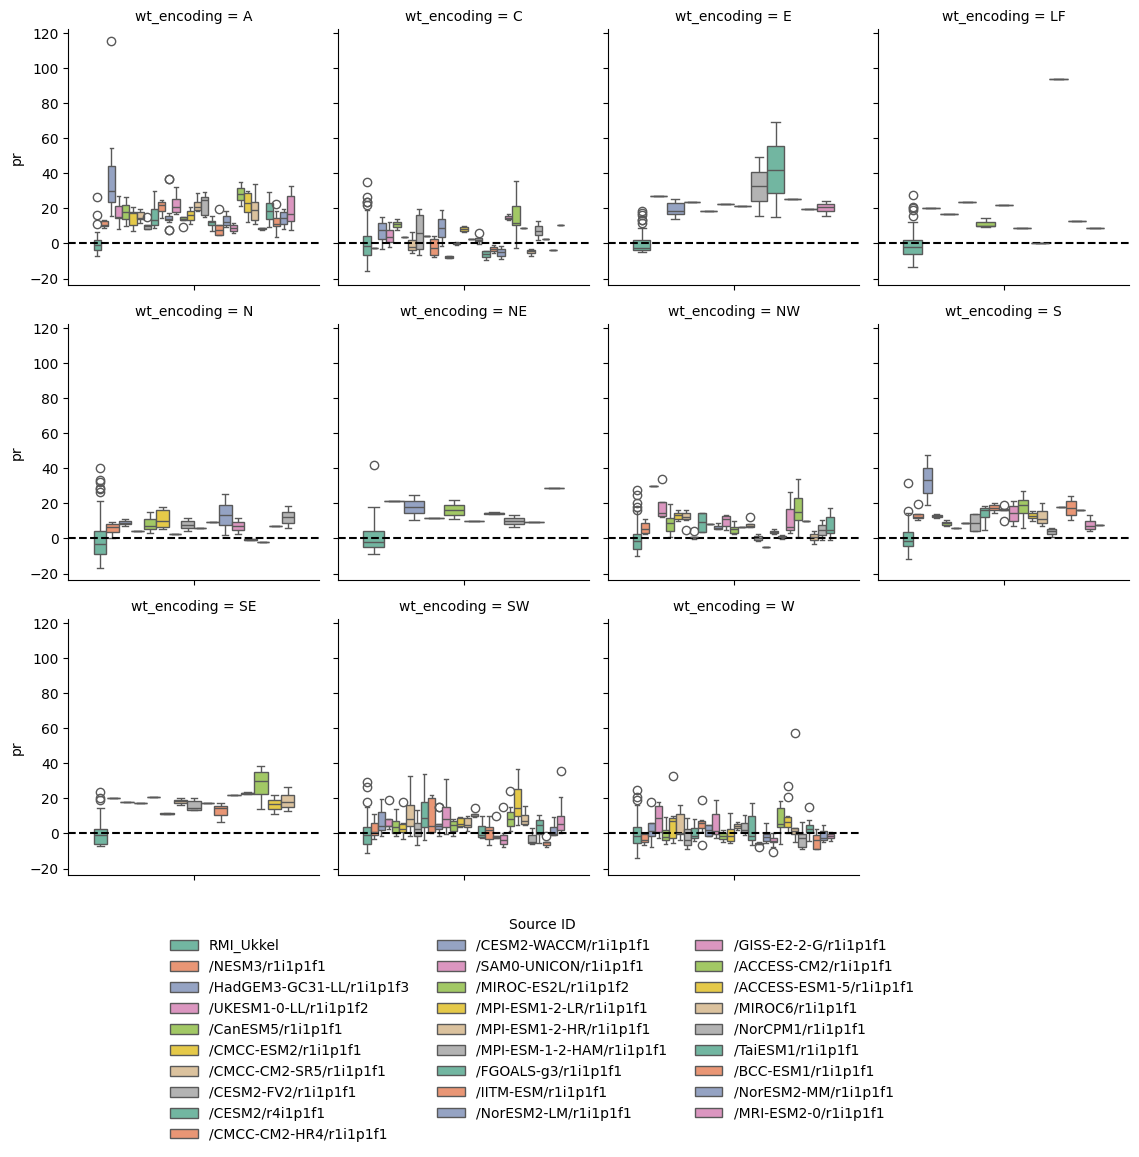

In [133]:
plot_data = pd.concat([df_pr_wt_Ukkel_max, df_merged], ignore_index=True)
avg_obs_values_per_wt = plot_data[plot_data["source_id"] == "RMI_Ukkel"].groupby("wt_encoding")["pr"].mean()
plot_data["pr"] = plot_data.apply(lambda x : x["pr"] - avg_obs_values_per_wt[x["wt_encoding"]], axis=1)

#Plot the maximum yearly precipitation for each year per WT
g = sns.FacetGrid(plot_data, col="wt_encoding", col_wrap=4)
g.map_dataframe(sns.boxplot, y="pr", hue="source_id", palette="Set2")
#Place the legend below the plot, also wrap the legend 
g.add_legend(title="Source ID", bbox_to_anchor=(0.5, -0.15), ncol=3)
#Add the number of 
#Add the zero line
for ax in g.axes.flat:
    ax.axhline(0, color="black", linestyle="--")
    ax.set_xlabel("")
plt.show()

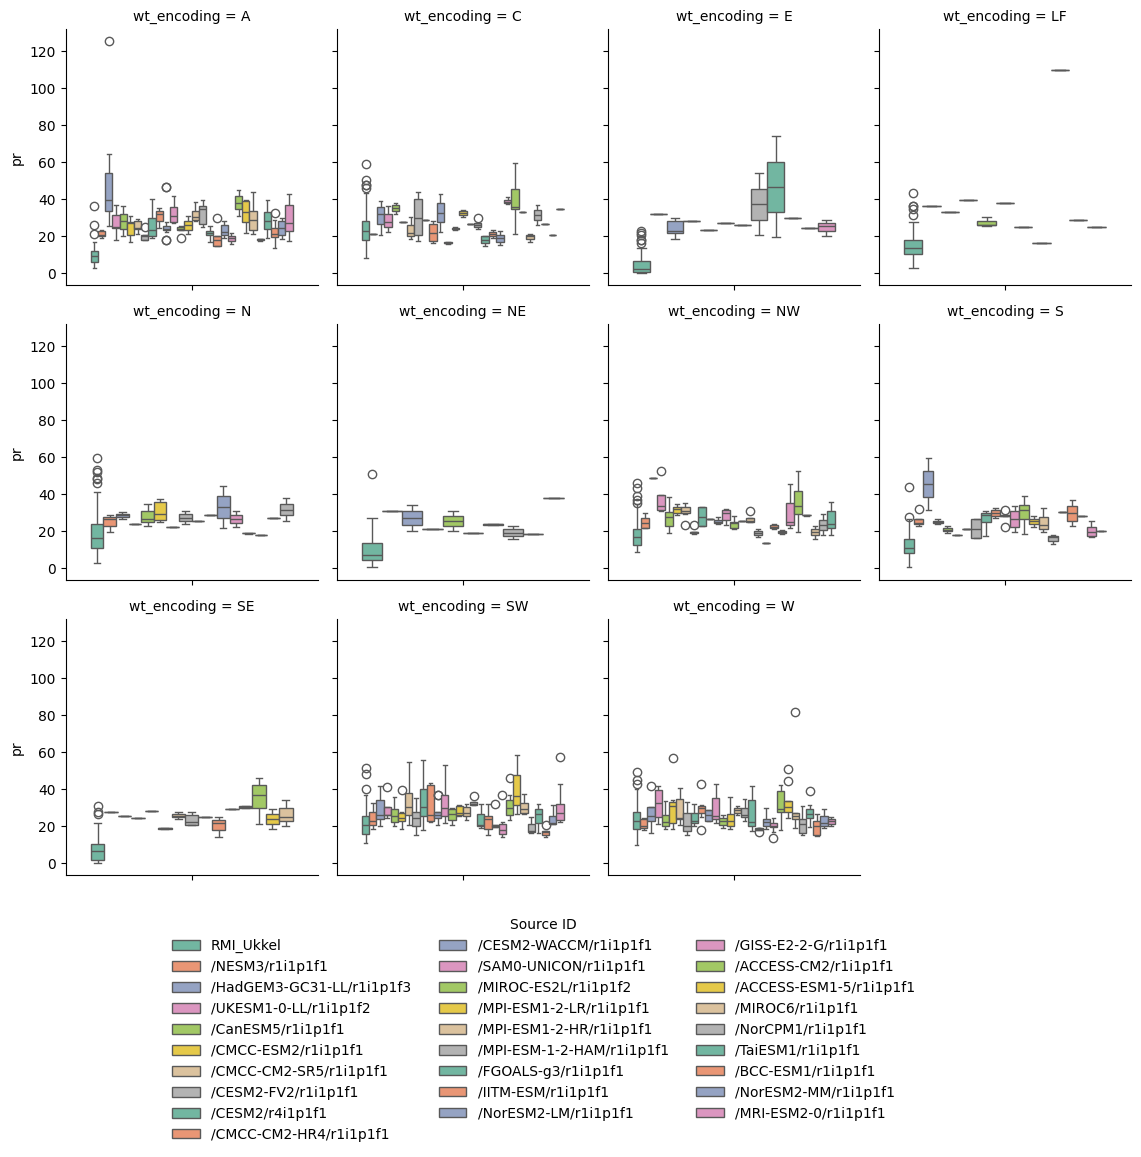

In [100]:
plot_data = pd.concat([df_pr_wt_Ukkel_max, df_merged], ignore_index=True)

#Plot the maximum yearly precipitation for each year per WT
g = sns.FacetGrid(plot_data, col="wt_encoding", col_wrap=4)
g.map_dataframe(sns.boxplot, y="pr", hue="source_id", palette="Set2")
#Place the legend below the plot, also wrap the legend 
g.add_legend(title="Source ID", bbox_to_anchor=(0.5, -0.15), ncol=3)
plt.show()

In [19]:
# Daily precipitation data
import numpy as np
df_pr_Ukkel_d = pd.read_csv('/home/kvandela/fileserver/home/Projects/WT_analysis/data/UCCLE-UKKEL_PRECIP_QUANTITY.csv')
df_pr_Ukkel_d = df_pr_Ukkel_d.rename(columns={'1':'PP1h10'})
df_pr_Ukkel_d.loc[df_pr_Ukkel_d['PP1h10'] < 0, 'PP1h10'] = np.nan
df_pr_Ukkel_d['Time'] = pd.to_datetime(df_pr_Ukkel_d[['year', 'month', 'day']])
df_pr_Ukkel_d = df_pr_Ukkel_d.set_index('Time')
df_pr_Ukkel_d

,year,month,day,PP1h10
Time,,,,
1951-01-01,1951,1,1,5.420
1951-01-02,1951,1,2,4.895
1951-01-03,1951,1,3,1.830
1951-01-04,1951,1,4,2.060
1951-01-05,1951,1,5,3.895
...,...,...,...,...
2023-12-27,2023,12,27,0.080
2023-12-28,2023,12,28,1.915
2023-12-29,2023,12,29,7.595


In [ ]:
#Get the yearly maximum of the daily precipitation
df_pr_Ukkel_d['year'] = df_pr_Ukkel_d.index.year
df_pr_Ukkel_d_max = df_pr_Ukkel_d.groupby('year')['PP1h10'].max().reset_index()
df_pr_Ukkel_d_max = df_pr_Ukkel_d_max.rename(columns={'PP1h10':'pr'})
df_pr_Ukkel_d_max["source_id"] = "RMI_UCCLE_observations"
df_pr_Ukkel_d_max

In [131]:
#Find where the precipitation is smaller than 5mm
df_t = df[df["lat"].notna()]
df_t[df_t['pr'] < 5]

,index,pr,lat,lon,source_id,latitude,longitude,time,date
445,2015-01-01 00:00:00,9.570347e-05,50.210526,5.00,/CESM2-FV2/r1i1p1f1,NaN,NaN,2015-01-01,2015-01-01
481,2015-01-01 00:00:00,1.210166e-01,50.418848,3.75,/CESM2/r1i1p1f1,NaN,NaN,2015-01-01,2015-01-01
517,2015-01-01 00:00:00,9.457003e-11,50.418848,3.75,/CESM2/r4i1p1f1,NaN,NaN,2015-01-01,2015-01-01
553,2015-01-01 00:00:00,1.275878e+00,50.418848,3.75,/CESM2/r11i1p1f1,NaN,NaN,2015-01-01,2015-01-01
624,2015-01-01 00:00:00,1.795399e-01,50.418848,3.75,/CESM2-WACCM/r1i1p1f1,NaN,NaN,2015-01-01,2015-01-01
660,2015-01-01 00:00:00,4.249465e+00,50.418848,3.75,/CESM2-WACCM/r2i1p1f1,NaN,NaN,2015-01-01,2015-01-01
696,2015-01-01 00:00:00,6.493288e-02,50.418848,3.75,/CESM2-WACCM/r3i1p1f1,NaN,NaN,2015-01-01,2015-01-01


In [ ]:
df_plot = df[df["lat"].notna()]
#All CESM2 models have data for 2015-01-01 which gives a very low value for the maximum 1-day precipitation amount of that year
#For now remove values below 5mm as these correspond to 2015-01-01 dates where there is only one value
df_plot = df_plot[df_plot['pr'] > 5]

df_plot = pd.concat([df_plot, df_pr_Ukkel_d_max], ignore_index=True)
df_plot


,index,pr,lat,lon,source_id,latitude,longitude,year
0,1980-01-01 00:00:00,26.704172,51.29438,3.75,/NESM3/r1i1p1f1,NaN,NaN,NaN
1,1981-01-01 00:00:00,32.020966,51.29438,3.75,/NESM3/r1i1p1f1,NaN,NaN,NaN
2,1982-01-01 00:00:00,22.095287,51.29438,3.75,/NESM3/r1i1p1f1,NaN,NaN,NaN
3,1983-01-01 00:00:00,23.159431,51.29438,3.75,/NESM3/r1i1p1f1,NaN,NaN,NaN
4,1984-01-01 00:00:00,22.573835,51.29438,3.75,/NESM3/r1i1p1f1,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
1873,NaN,34.090000,NaN,NaN,RMI_UCCLE_observations,NaN,NaN,2019.0
1874,NaN,51.875000,NaN,NaN,RMI_UCCLE_observations,NaN,NaN,2020.0
1875,NaN,46.150000,NaN,NaN,RMI_UCCLE_observations,NaN,NaN,2021.0
1876,NaN,22.730000,NaN,NaN,RMI_UCCLE_observations,NaN,NaN,2022.0


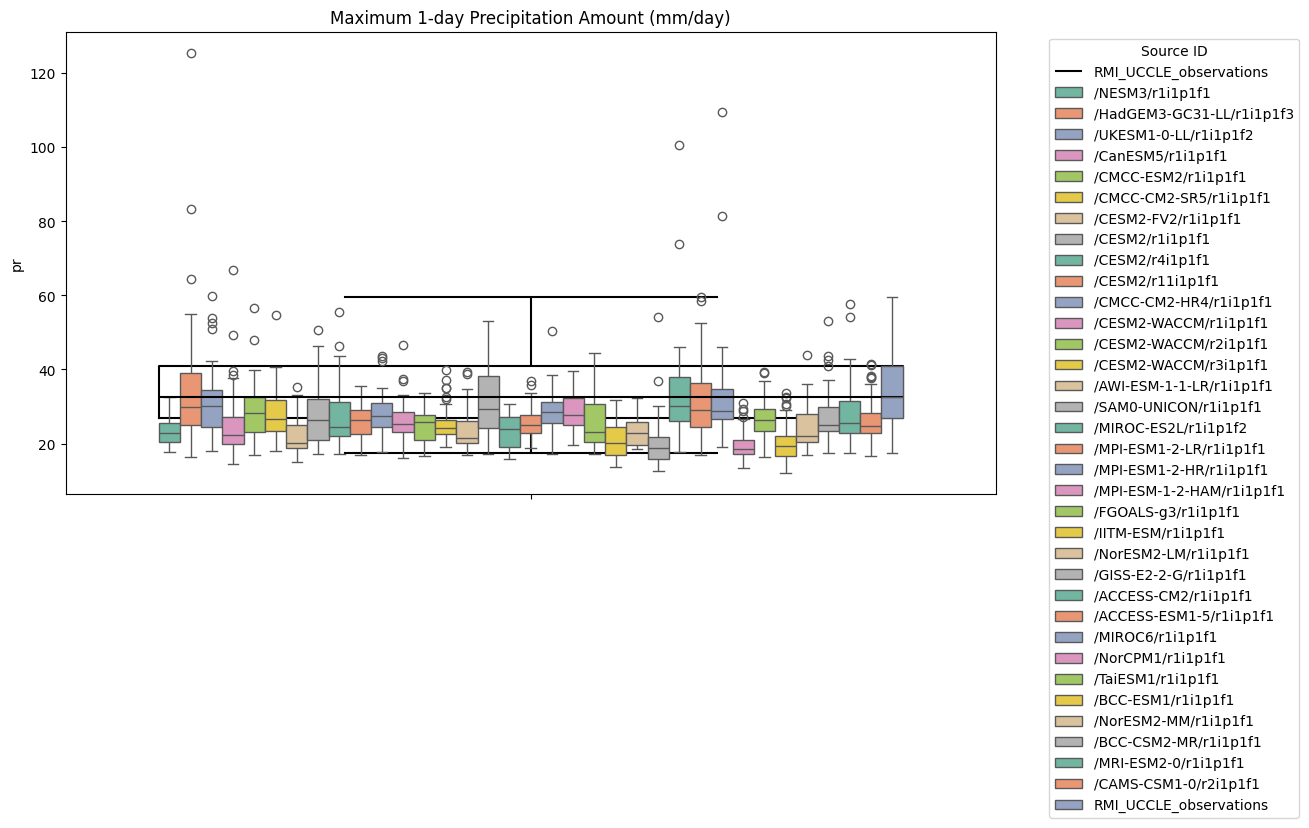

In [ ]:

plt.figure(figsize=(12, 6))
sns.boxplot(y="pr", data=df_pr_Ukkel_d_max, color="grey", fill=False, label="RMI_UCCLE_observations")
sns.boxplot(y="pr", data=df_plot, hue="source_id", palette="Set2")
plt.title("Maximum 1-day Precipitation Amount (mm/day)")
#Place the legend outside the plot to the right
plt.legend(title="Source ID", bbox_to_anchor=(1.05, 1), loc='upper left')
#Save the figure
plt.savefig("max_1day_precipitation_amount.png", dpi=300, bbox_inches="tight")